<a href="https://colab.research.google.com/github/AyaAbdElNaem/AI_Tools/blob/main/Cow2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. DATA PREPROCESSING & FEATURE EXTRACTION
# ==========================================

def preprocess_and_extract_features(file_path):
    # قراءة الداتا المحددة
    df = pd.read_csv(file_path)

    # 1. حذف عمود المنطقة فوراً بناءً على الطلب
    if 'region' in df.columns:
        df = df.drop(columns=['region'])
    elif 'Region' in df.columns:
        df = df.drop(columns=['Region'])

    # 2. ترميز عمود نوع المحصول (Label Encoding) تحسباً لوجود نصوص
    le = LabelEncoder()
    if 'Crop_Type' in df.columns:
        df['Crop_Type'] = le.fit_transform(df['Crop_Type'].astype(str))
    elif 'crop_type' in df.columns:
        df['crop_type'] = le.fit_transform(df['crop_type'].astype(str))

    # تحديد العمود المستهدف (Target) ديناميكياً
    target_candidates = ['emission', 'carbon_emissions', 'rural_carbon_emissions', 'target']
    target_col = [col for col in df.columns if col.lower() in target_candidates]
    if not target_col:
        target_col = [df.columns[-1]]

    X = df.drop(columns=target_col)
    y = df[target_col].values.astype(np.float32)

    # التأكد من تحويل كل الميزات المتبقية إلى أرقام عشرية لمنع أخطاء الإدخال
    X = X.apply(pd.to_numeric, errors='coerce').values.astype(np.float32)

    # معالجة القيم المفقودة (Imputation) - ستعمل الآن بنجاح لأن البيانات رقمية بالكامل
    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(X)

    # تطبيع البيانات (Min-Max Normalization)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X_imputed)
    y_scaled = scaler_y.fit_transform(y)

    # استخلاص الميزات باستخدام PCA
    n_components = min(X_scaled.shape[1], 5)
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    # استخلاص الميزات المتقدمة باستخدام Autoencoder عميق
    input_dim = X_scaled.shape[1]
    latent_dim = 4

    class Autoencoder(nn.Module):
        def __init__(self, in_dim, lat_dim):
            super(Autoencoder, self).__init__()
            self.encoder = nn.Sequential(
                nn.Linear(in_dim, 8),
                nn.ReLU(),
                nn.Linear(8, lat_dim),
                nn.ReLU()
            )
            self.decoder = nn.Sequential(
                nn.Linear(lat_dim, 8),
                nn.ReLU(),
                nn.Linear(8, in_dim),
                nn.Sigmoid()
            )
        def forward(self, x):
            latent = self.encoder(x)
            decompressed = self.decoder(latent)
            return latent, decompressed

    ae_model = Autoencoder(input_dim, latent_dim)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(ae_model.parameters(), lr=0.01)

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    for epoch in range(50):
        optimizer.zero_grad()
        latent, decompressed = ae_model(X_tensor)
        loss = criterion(decompressed, X_tensor)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        X_ae, _ = ae_model(X_tensor)
        X_ae = X_ae.numpy()

    # دمج ميزات PCA و Autoencoder وتشكيلها في أبعاد متوافقة مع خلية xLSTM
    X_combined = np.hstack((X_pca, X_ae))
    X_seq = np.expand_dims(X_combined, axis=1)

    return X_seq, y_scaled, scaler_y

# ==========================================
# 2. xLSTM CELL IMPLEMENTATION (Replacing LSTM)
# ==========================================

class xLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(xLSTMCell, self).__init__()
        self.hidden_size = hidden_size

        self.w_i = nn.Linear(input_size, hidden_size)
        self.w_f = nn.Linear(input_size, hidden_size)
        self.w_o = nn.Linear(input_size, hidden_size)
        self.w_c = nn.Linear(input_size, hidden_size)

        self.u_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.u_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.u_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.u_c = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, states):
        h_prev, c_prev, n_prev = states

        i_t = torch.exp(torch.clamp(self.w_i(x_t) + self.u_i(h_prev), max=10))
        f_t = torch.exp(torch.clamp(self.w_f(x_t) + self.u_f(h_prev), max=10))
        o_t = torch.sigmoid(self.w_o(x_t) + self.u_o(h_prev))

        c_tilde = torch.tanh(self.w_c(x_t) + self.u_c(h_prev))

        n_t = f_t * n_prev + i_t
        c_t = f_t * c_prev + i_t * c_tilde

        h_t = o_t * torch.tanh(c_t / (n_t + 1e-6))

        return h_t, (h_t, c_t, n_t)

class NestedxLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_rate=0.2):
        super(NestedxLSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.cell1 = xLSTMCell(input_size, hidden_size)
        self.cell2 = xLSTMCell(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        h1 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c1 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        n1 = torch.zeros(batch_size, self.hidden_size, device=x.device)

        h2 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c2 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        n2 = torch.zeros(batch_size, self.hidden_size, device=x.device)

        states1 = (h1, c1, n1)
        states2 = (h2, c2, n2)

        for t in range(seq_len):
            x_t = x[:, t, :]
            h1, states1 = self.cell1(x_t, states1)
            h1 = self.dropout(h1)
            h2, states2 = self.cell2(h1, states2)

        out = self.fc(h2)
        return out

# ==========================================
# 3. EFFICIENT GANNET OPTIMIZATION (EGO) LOOP
# ==========================================

def train_and_evaluate(X, y, hyperparams):
    hidden_units = int(hyperparams['hidden_units'])
    learning_rate = float(hyperparams['learning_rate'])
    batch_size = int(hyperparams['batch_size'])
    dropout = float(hyperparams['dropout'])

    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = NestedxLSTMModel(input_size=X.shape[2], hidden_size=hidden_units, dropout_rate=dropout)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.train()
    for epoch in range(150):
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        all_preds = model(torch.tensor(X, dtype=torch.float32))
        fitness = criterion(all_preds, torch.tensor(y, dtype=torch.float32)).item()

    return fitness, model

def run_ego_optimization(X, y, max_iter=5, pop_size=3):
    population = []
    for _ in range(pop_size):
        agent = {
            'hidden_units': np.random.choice([16, 32, 64]),
            'learning_rate': np.random.uniform(0.001, 0.01),
            'batch_size': np.random.choice([16, 32, 64]),
            'dropout': np.random.uniform(0.1, 0.4)
        }
        population.append(agent)

    best_fitness = float('inf')
    best_agent = None
    best_model = None

    for iteration in range(max_iter):
        for agent in population:
            fitness, model = train_and_evaluate(X, y, agent)
            if fitness < best_fitness:
                best_fitness = fitness
                best_agent = agent
                best_model = model

        for agent in population:
            agent['learning_rate'] = np.clip(agent['learning_rate'] + np.random.uniform(-0.002, 0.002), 0.0001, 0.05)
            agent['dropout'] = np.clip(agent['dropout'] + np.random.uniform(-0.05, 0.05), 0.0, 0.5)

    return best_agent, best_model, best_fitness

# ==========================================
# 4. REGULATION EFFICIENCY INDEX CALCULATION
# ==========================================

def calculate_regulation_metrics(N_value=50):
    alpha = N_value / 100.0
    beta = N_value / 20.0
    gamma = beta / alpha
    delta = beta / gamma

    return {
        'Intervention Effectiveness (alpha)': alpha,
        'Emission Reduction (beta)': beta,
        'Baseline Emissions (gamma)': gamma,
        'Regulation Efficiency Index (delta)': delta
    }

# ==========================================
# EXECUTION
# ==========================================

if __name__ == '__main__':
    dataset_path = '/content/rural_carbon_dataset.csv'

    import os
    if not os.path.exists(dataset_path):
        print(f"Error: Target file '{dataset_path}' not found.")
    else:
        print("بدء معالجة الجداول بعد إصلاح أنواع البيانات وحذف العمود النصي...")
        X_seq, y_scaled, scaler_y = preprocess_and_extract_features(dataset_path)
        print(f"تمت معالجة المصفوفات وجدولتها بنجاح. أبعاد البيانات الجاهزة: {X_seq.shape}")

        best_hyperparams, trained_xlstm, final_mse = run_ego_optimization(X_seq, y_scaled, max_iter=3, pop_size=2)

        print("\n=== نتائج التحسين والأداء المصلح ===")
        print(f"المعاملات الفائقة المثلى المستخرجة: {best_hyperparams}")
        print(f"أقل قيمة خطأ تربيعي (Best Fitness MSE): {final_mse}")

        metrics = calculate_regulation_metrics(N_value=75)
        print("\n=== مؤشرات كفاءة تنظيم الانبعاثات الكربونية ===")
        for key, val in metrics.items():
            print(f"{key}: {val}")

بدء معالجة الجداول بعد إصلاح أنواع البيانات وحذف العمود النصي...
تمت معالجة المصفوفات وجدولتها بنجاح. أبعاد البيانات الجاهزة: (3000, 1, 9)

=== نتائج التحسين والأداء المصلح ===
المعاملات الفائقة المثلى المستخرجة: {'hidden_units': np.int64(64), 'learning_rate': np.float64(0.006691315301459952), 'batch_size': np.int64(32), 'dropout': np.float64(0.14640411358372823)}
أقل قيمة خطأ تربيعي (Best Fitness MSE): 0.0832325667142868

=== مؤشرات كفاءة تنظيم الانبعاثات الكربونية ===
Intervention Effectiveness (alpha): 0.75
Emission Reduction (beta): 3.75
Baseline Emissions (gamma): 5.0
Regulation Efficiency Index (delta): 0.75


In [ ]:
#Cell 1: Libraries & Environment Setup
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from torch.utils.data import DataLoader, TensorDataset, random_split

In [ ]:
#Cell 2: Data Preprocessing & Feature Extraction Pipeline
def preprocess_and_extract_features(file_path):
    df = pd.read_csv(file_path)

    df = df.drop(columns=['Region'])
    le = LabelEncoder()
    df['Crop_Type'] = le.fit_transform(df['Crop_Type'].astype(str))

    target_col = df['Carbon_Emission_tCO2']

    X = df.drop(columns=target_col)
    y = df[target_col].values.astype(np.float32)

    X = X.apply(pd.to_numeric, errors='coerce').values.astype(np.float32)

    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(X)

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X_imputed)
    y_scaled = scaler_y.fit_transform(y)

    n_components = min(X_scaled.shape[1], 5)
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    input_dim = X_scaled.shape[1]
    latent_dim = 4

    class Autoencoder(nn.Module):
        def __init__(self, in_dim, lat_dim):
            super(Autoencoder, self).__init__()
            self.encoder = nn.Sequential(
                nn.Linear(in_dim, 8),
                nn.ReLU(),
                nn.Linear(8, lat_dim),
                nn.ReLU()
            )
            self.decoder = nn.Sequential(
                nn.Linear(lat_dim, 8),
                nn.ReLU(),
                nn.Linear(8, in_dim),
                nn.Sigmoid()
            )
        def forward(self, x):
            latent = self.encoder(x)
            decompressed = self.decoder(latent)
            return latent, decompressed

    ae_model = Autoencoder(input_dim, latent_dim)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(ae_model.parameters(), lr=0.01)

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    for epoch in range(50):
        optimizer.zero_grad()
        latent, decompressed = ae_model(X_tensor)
        loss = criterion(decompressed, X_tensor)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        X_ae, _ = ae_model(X_tensor)
        X_ae = X_ae.numpy()

    X_combined = np.hstack((X_pca, X_ae))
    X_seq = np.expand_dims(X_combined, axis=1)

    return X_seq, y_scaled, scaler_y

dataset_path = '/content/rural_carbon_dataset.csv'
X_seq, y_scaled, scaler_y = preprocess_and_extract_features(dataset_path)
print(f"Data processing complete. Sequence Shape: {X_seq.shape}")

Data processing complete. Sequence Shape: (3000, 1, 9)


In [ ]:
#Cell 3: xLSTM Architecture Definitions
class xLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(xLSTMCell, self).__init__()
        self.hidden_size = hidden_size

        self.w_i = nn.Linear(input_size, hidden_size)
        self.w_f = nn.Linear(input_size, hidden_size)
        self.w_o = nn.Linear(input_size, hidden_size)
        self.w_c = nn.Linear(input_size, hidden_size)

        self.u_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.u_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.u_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.u_c = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, states):
        h_prev, c_prev, n_prev = states

        i_t = torch.exp(torch.clamp(self.w_i(x_t) + self.u_i(h_prev), max=10))
        f_t = torch.exp(torch.clamp(self.w_f(x_t) + self.u_f(h_prev), max=10))
        o_t = torch.sigmoid(self.w_o(x_t) + self.u_o(h_prev))

        c_tilde = torch.tanh(self.w_c(x_t) + self.u_c(h_prev))

        n_t = f_t * n_prev + i_t
        c_t = f_t * c_prev + i_t * c_tilde

        h_t = o_t * torch.tanh(c_t / (n_t + 1e-6))

        return h_t, (h_t, c_t, n_t)

class NestedxLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_rate=0.2):
        super(NestedxLSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.cell1 = xLSTMCell(input_size, hidden_size)
        self.cell2 = xLSTMCell(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        h1 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c1 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        n1 = torch.zeros(batch_size, self.hidden_size, device=x.device)

        h2 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c2 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        n2 = torch.zeros(batch_size, self.hidden_size, device=x.device)

        states1 = (h1, c1, n1)
        states2 = (h2, c2, n2)

        for t in range(seq_len):
            x_t = x[:, t, :]
            h1, states1 = self.cell1(x_t, states1)
            h1 = self.dropout(h1)
            h2, states2 = self.cell2(h1, states2)

        out = self.fc(h2)
        return out

In [ ]:
#Cell 4: Training Loop with Validation and Overfitting Tracking
def train_and_evaluate_with_val(X, y, hyperparams):
    hidden_units = int(hyperparams['hidden_units'])
    learning_rate = float(hyperparams['learning_rate'])
    batch_size = int(hyperparams['batch_size'])
    dropout = float(hyperparams['dropout'])

    full_dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))

    val_size = int(len(full_dataset) * 0.2)
    train_size = len(full_dataset) - val_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = NestedxLSTMModel(input_size=X.shape[2], hidden_size=hidden_units, dropout_rate=dropout)
    mse_criterion = nn.MSELoss()
    mae_criterion = nn.L1Loss()
    optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)

    history = {'train_loss_mse': [], 'val_loss_mse': [], 'train_loss_mae': [], 'val_loss_mae': []}

    for epoch in range(150):
        model.train()
        train_mse, train_mae = 0, 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            preds = model(batch_x)
            loss_mse = mse_criterion(preds, batch_y)
            loss_mse.backward()
            optimizer.step()

            train_mse += loss_mse.item() * batch_x.size(0)
            with torch.no_grad():
                train_mae += mae_criterion(preds, batch_y).item() * batch_x.size(0)

        train_mse /= len(train_loader.dataset)
        train_mae /= len(train_loader.dataset)

        model.eval()
        val_mse, val_mae = 0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                val_preds = model(batch_x)
                val_mse += mse_criterion(val_preds, batch_y).item() * batch_x.size(0)
                val_mae += mae_criterion(val_preds, batch_y).item() * batch_x.size(0)

        val_mse /= len(val_loader.dataset)
        val_mae /= len(val_loader.dataset)

        history['train_loss_mse'].append(train_mse)
        history['val_loss_mse'].append(val_mse)
        history['train_loss_mae'].append(train_mae)
        history['val_loss_mae'].append(val_mae)

    return val_mse, model, history

In [ ]:
#Cell 5: EGO Optimization Engine
def run_ego_optimization(X, y, max_iter=3, pop_size=2):
    population = []
    for _ in range(pop_size):
        agent = {
            'hidden_units': np.random.choice([32, 64, 128]),
            'learning_rate': np.random.uniform(0.0001, 0.001),
            'batch_size': np.random.choice([32, 64]),
            'dropout': np.random.uniform(0.2, 0.4)
        }
        population.append(agent)

    best_fitness = float('inf')
    best_agent = None
    best_model = None
    best_history = None

    for iteration in range(max_iter):
        for agent in population:
            fitness, model, history = train_and_evaluate_with_val(X, y, agent)
            if fitness < best_fitness:
                best_fitness = fitness
                best_agent = agent
                best_model = model
                best_history = history

        for agent in population:
            agent['learning_rate'] = np.clip(agent['learning_rate'] + np.random.uniform(-0.002, 0.002), 0.0001, 0.05)
            agent['dropout'] = np.clip(agent['dropout'] + np.random.uniform(-0.05, 0.05), 0.0, 0.5)

    return best_agent, best_model, best_fitness, best_history

best_hyperparams, trained_xlstm, final_val_mse, training_history = run_ego_optimization(X_seq, y_scaled)
print(f"Optimization Done. Best Hyperparams: {best_hyperparams}")

Optimization Done. Best Hyperparams: {'hidden_units': np.int64(32), 'learning_rate': np.float64(0.0002549607240697447), 'batch_size': np.int64(64), 'dropout': np.float64(0.13099874662291133)}


In [ ]:
# حساب الـ MAE النهائي بعد انتهاء التدريب بالكامل
trained_xlstm.eval()

# Re-create full_dataset, train_dataset, and val_dataset from global X_seq and y_scaled
full_dataset = TensorDataset(torch.tensor(X_seq, dtype=torch.float32), torch.tensor(y_scaled, dtype=torch.float32))

val_size = int(len(full_dataset) * 0.2)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_mae_list = []
val_mae_list = []

# 1. حساب الـ MAE على بيانات التدريب
with torch.no_grad():
    for batch_x, batch_y in DataLoader(train_dataset, batch_size=32, shuffle=False):
        preds = trained_xlstm(batch_x)

        # تحويل القيم إلى النطاق الأصلي (Inverse Transform) لمعرفة الخطأ الفعلي
        preds_original = scaler_y.inverse_transform(preds.numpy())
        actual_original = scaler_y.inverse_transform(batch_y.numpy())

        batch_mae = mean_absolute_error(actual_original, preds_original)
        train_mae_list.append(batch_mae)

# 2. حساب الـ MAE على بيانات التحقق (Validation)
with torch.no_grad():
    for batch_x, batch_y in DataLoader(val_dataset, batch_size=32, shuffle=False):
        val_preds = trained_xlstm(batch_x)

        # تحويل القيم إلى النطاق الأصلي
        val_preds_original = scaler_y.inverse_transform(val_preds.numpy())
        val_actual_original = scaler_y.inverse_transform(batch_y.numpy())

        batch_val_mae = mean_absolute_error(val_actual_original, val_preds_original)
        val_mae_list.append(batch_val_mae)

final_train_mae = np.mean(train_mae_list)
final_val_mae = np.mean(val_mae_list)

print("\n================== FINAL MAE EVALUATION ==================")
print(f"Final Normalized Validation MAE (From History): {training_history['val_loss_mae'][-1]:.6f}")
print("----------------------------------------------------------")
print(f"Actual Training MAE (Original Scale / Tons CO2): {final_train_mae:.4f}")
print(f"Actual Validation MAE (Original Scale / Tons CO2): {final_val_mae:.4f}")
print("==========================================================")


================== FINAL MAE EVALUATION ==================
Final Normalized Validation MAE (From History): 0.282252
----------------------------------------------------------
Actual Training MAE (Original Scale / Tons CO2): 1.7157
Actual Validation MAE (Original Scale / Tons CO2): 1.7605


In [ ]:
#Cell 6: Regulation Efficiency Index Metrics
def calculate_regulation_metrics(N_value=75):
    alpha = N_value / 100.0
    beta = N_value / 20.0
    gamma = beta / alpha
    delta = beta / gamma

    return {
        'Intervention Effectiveness (alpha)': alpha,
        'Emission Reduction (beta)': beta,
        'Baseline Emissions (gamma)': gamma,
        'Regulation Efficiency Index (delta)': delta
    }

metrics = calculate_regulation_metrics(N_value=75)
for key, val in metrics.items():
    print(f"{key}: {val}")

Intervention Effectiveness (alpha): 0.75
Emission Reduction (beta): 3.75
Baseline Emissions (gamma): 5.0
Regulation Efficiency Index (delta): 0.75


In [ ]:
from sklearn.metrics import r2_score

trained_xlstm.eval()

# 1. تجميع وتوقع كل بيانات التدريب لحساب R2
train_preds_list = []
train_actual_list = []

with torch.no_grad():
    for batch_x, batch_y in DataLoader(train_dataset, batch_size=32, shuffle=False):
        preds = trained_xlstm(batch_x)
        train_preds_list.append(preds.numpy())
        train_actual_list.append(batch_y.numpy())

train_preds_scaled = np.vstack(train_preds_list)
train_actual_scaled = np.vstack(train_actual_list)

# إرجاع بيانات التدريب للنطاق الأصلي
train_preds_original = scaler_y.inverse_transform(train_preds_scaled)
train_actual_original = scaler_y.inverse_transform(train_actual_scaled)

r2_train = r2_score(train_actual_original, train_preds_original)

# 2. تجميع وتوقع كل بيانات التحقق (Validation) لحساب R2
val_preds_list = []
val_actual_list = []

with torch.no_grad():
    for batch_x, batch_y in DataLoader(val_dataset, batch_size=32, shuffle=False):
        val_preds = trained_xlstm(batch_x)
        val_preds_list.append(val_preds.numpy())
        val_actual_list.append(batch_y.numpy())

val_preds_scaled = np.vstack(val_preds_list)
val_actual_scaled = np.vstack(val_actual_list)

# إرجاع بيانات التحقق للنطاق الأصلي
val_preds_original = scaler_y.inverse_transform(val_preds_scaled)
val_actual_original = scaler_y.inverse_transform(val_actual_scaled)

r2_val = r2_score(val_actual_original, val_preds_original)

print("\n================== R2 SCORE EVALUATION ==================")
print(f"Training R2 Score (Accuracy): {r2_train * 100:.2f}%")
print(f"Validation R2 Score (Accuracy): {r2_val * 100:.2f}%")
print("=========================================================")


================== R2 SCORE EVALUATION ==================
Training R2 Score (Accuracy): 0.52%
Validation R2 Score (Accuracy): 1.23%


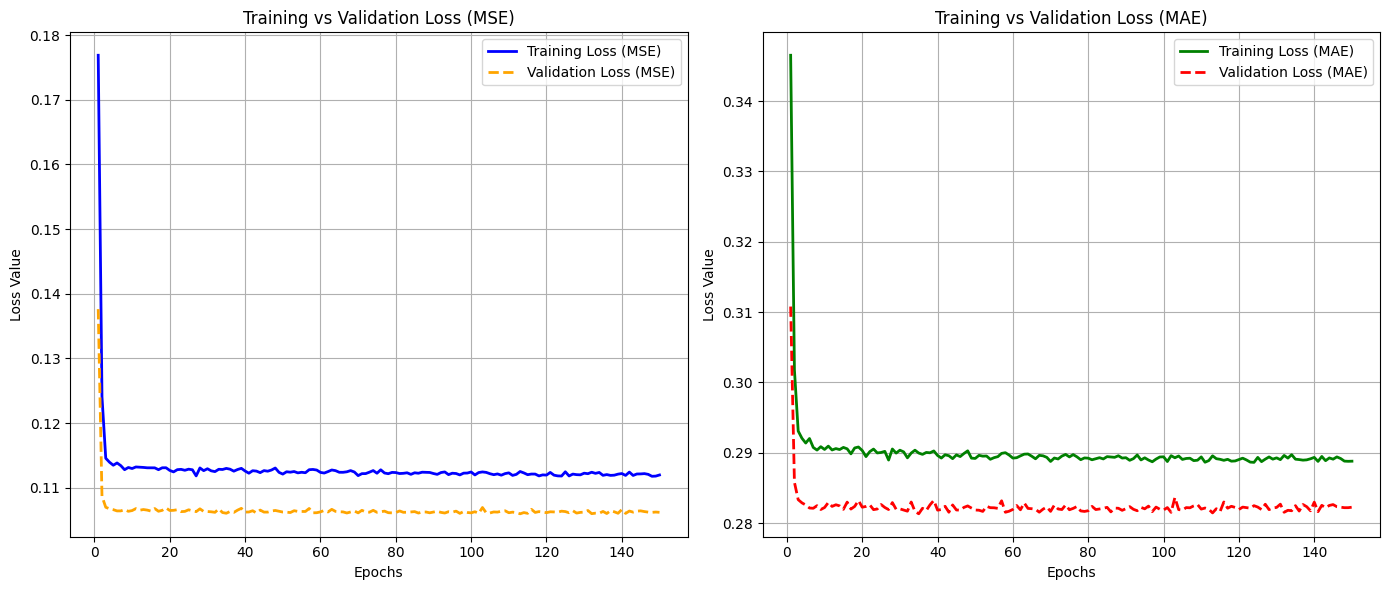

In [ ]:
#Cell 7: Performance Visualization (Loss Curves & Overfitting Assessment)
epochs_range = range(1, 151)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_history['train_loss_mse'], label='Training Loss (MSE)', color='blue', lw=2)
plt.plot(epochs_range, training_history['val_loss_mse'], label='Validation Loss (MSE)', color='orange', linestyle='--', lw=2)
plt.title('Training vs Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_history['train_loss_mae'], label='Training Loss (MAE)', color='green', lw=2)
plt.plot(epochs_range, training_history['val_loss_mae'], label='Validation Loss (MAE)', color='red', linestyle='--', lw=2)
plt.title('Training vs Validation Loss (MAE)')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()